In [1]:
import pandas as pd
import tensorflow as tf
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

I0000 00:00:1781797262.658731 1112798 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781797262.687287 1112798 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781797263.335312 1112798 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [8]:
# 0. Cargar los metadatos de la RM 
df_val_md =  pd.read_parquet("../data/processed/val_RM_metadata.parquet")
metadata_cols = ["year", "fecha_hora", "region", "comuna", "region_bne"]
df_metadata = df_val_md[metadata_cols].copy()

# 1. Cargar el modelo entrenado y el scaler de la variable "Y" (Demanda)
model = tf.keras.models.load_model('../models/best_merlin_mlp_RM.keras')
scaler_y = joblib.load('../models/scaler_demand_RM.pkl')
temp_scaler = joblib.load("../models/scaler_temp_RM.pkl")

# 2. Cargar datos de Validación (o Test)
df_scaled = df_val_md.copy()
temp_columns = [col for col in df_scaled.columns if 'temp' in col.lower()]
df_scaled[temp_columns] = temp_scaler.transform(df_scaled[temp_columns])
X_val_scaled = df_scaled.drop(columns=['demanda_mwh'] + metadata_cols).values
y_val_real = df_val_md['demanda_mwh'].values

# 3. Hacer predicciones (el resultado es un valor entre 0 y 1)
y_pred_scaled = model.predict(X_val_scaled)

# 4. DEVOLVER A ESCALA ORIGINAL (MWh)
# Transformamos la matriz (N, ) a (N, 1) porque scikit-learn lo exige
y_pred_real = scaler_y.inverse_transform(y_pred_scaled).flatten()

# 4. El Cruce: Reconstruir el DataFrame con su Datetime y Comuna
df_resultados = df_metadata.copy()
df_resultados['demanda_real_mwh'] = y_val_real
df_resultados['demanda_pred_mwh'] = y_pred_real

print("Muestra de resultados por comuna y hora:")
print(df_resultados.head())

10678/10678 ━━━━━━━━━━━━━━━━━━━━ 4s 316us/step
Muestra de resultados por comuna y hora:
   year fecha_hora                     region      comuna region_bne  \
0  2021 2021-01-01  METROPOLITANA DE SANTIAGO   TALAGANTE         RM   
1  2021 2021-01-01  METROPOLITANA DE SANTIAGO  LAS CONDES         RM   
2  2021 2021-01-01  METROPOLITANA DE SANTIAGO  LA FLORIDA         RM   
3  2021 2021-01-01  METROPOLITANA DE SANTIAGO      PIRQUE         RM   
4  2021 2021-01-01  METROPOLITANA DE SANTIAGO       MAIPÚ         RM   

   demanda_real_mwh  demanda_pred_mwh  
0         25.607116         52.932480  
1        182.925185         53.529236  
2         66.324498         53.325283  
3          5.626940         53.799622  
4        147.286794         52.294918  


In [10]:
# 5. Agregación Regional (Suma de las 52 comunas hora por hora)
# Agrupamos por 'valid_time' y sumamos los valores de las comunas
df_serie_regional = df_resultados.groupby('fecha_hora')[['demanda_real_mwh', 'demanda_pred_mwh']].sum().reset_index()

# Ordenar cronológicamente para garantizar la estructura de serie de tiempo
df_serie_regional = df_serie_regional.sort_values('fecha_hora').reset_index(drop=True)

print("\nSerie de Tiempo Agregada para la Región Metropolitana (RM):")
print(df_serie_regional.head())


Serie de Tiempo Agregada para la Región Metropolitana (RM):
           fecha_hora  demanda_real_mwh  demanda_pred_mwh
0 2021-01-01 00:00:00       2061.639996       2067.898438
1 2021-01-01 01:00:00       1986.212942       1867.587646
2 2021-01-01 02:00:00       1889.369513       1733.851196
3 2021-01-01 03:00:00       1791.401545       1764.327637
4 2021-01-01 04:00:00       1705.934706       1863.962524


--- Desempeño a nivel comunal:
MAE:  42.74 MWh (Error promedio por hora)
RMSE: 59.41 MWh
--- Desempeño a nivel regional:
MAE:  261.40 MWh (Error promedio por hora)
RMSE: 330.14 MWh


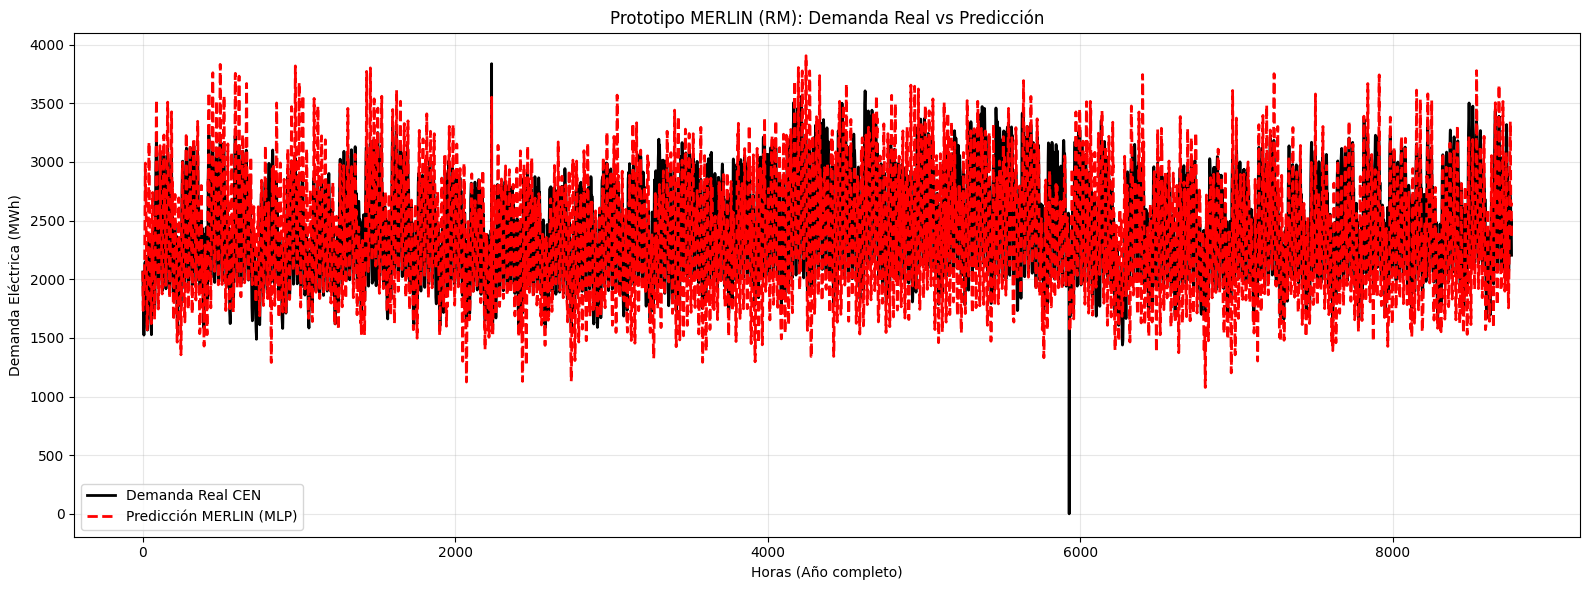

In [29]:
# 5. Calcular Métricas de Desempeño
mae_comunal = mean_absolute_error(y_val_real, y_pred_real)
rmse_comunal = np.sqrt(mean_squared_error(y_val_real, y_pred_real))
print(f"--- Desempeño a nivel comunal:")
print(f"MAE:  {mae_comunal:.2f} MWh (Error promedio por hora)")
print(f"RMSE: {rmse_comunal:.2f} MWh")

y_val_real_reg = df_serie_regional["demanda_real_mwh"].values
y_pred_real_reg = df_serie_regional["demanda_pred_mwh"].values
mae_regional = mean_absolute_error(y_val_real_reg, y_pred_real_reg)
rmse_regional = np.sqrt(mean_squared_error(y_val_real_reg, y_pred_real_reg))
print(f"--- Desempeño a nivel regional:")
print(f"MAE:  {mae_regional:.2f} MWh (Error promedio por hora)")
print(f"RMSE: {rmse_regional:.2f} MWh")

# 6. Gráfico de Verificación Fina (Visualizar 1 semana)
# Supongamos que queremos ver las primeras 168 horas (1 semana)
inicio = 0 # Un punto arbitrario (ej. a mitad de año)
fin = 8760

plt.figure(figsize=(16, 6))
plt.plot(y_val_real_reg[inicio:fin], label='Demanda Real CEN', color='black', linewidth=2)
plt.plot(y_pred_real_reg[inicio:fin], label='Predicción MERLIN (MLP)', color='red', linestyle='--', linewidth=2)

plt.title('Prototipo MERLIN (RM): Demanda Real vs Predicción')
plt.xlabel('Horas (Año completo)')
plt.ylabel('Demanda Eléctrica (MWh)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
# Validación con la BRE
# 1. Agregar las series de tiempo en suma anual 
total_anual_reg_val = y_val_real_reg.sum() / 1e6 # a TWh 
total_anual_reg_pred = y_pred_real_reg.sum() / 1e6  # a TWh

# 2. Cargar los datos de la BRE
data_bre = pd.read_csv("../data/raw/wp2_elec_input_sector_shares_raw.csv")

# 3. Pivotear tabla para facilitar procesamiento
df_sec = data_bre.pivot_table(
    index=['año', 'región'], 
    columns='sector', 
    values='valor', 
    aggfunc='sum'
).reset_index()

# 4. Cálculo de totales anuales de la RM
sectores = ['Industrial', 'Residencial', 'Comercial', 'Público', 'Transporte']
df_sec['total_consumo_region'] = df_sec[sectores].sum(axis=1)
total_RM = df_sec["total_consumo_region"][(df_sec["región"] == "RM") & (df_sec["año"] == 2021)].values[0]/1e3  # a TWh
mape_BRE = 100 * abs(total_anual_reg_pred - total_RM) / total_RM

print("--- Validación del modelo con BRE (RM)")
print(f"Totales anuales del CEN: {total_anual_reg_val:.2f} TWh")
print(f"Totales anuales de MERLIN_EDM: {total_anual_reg_pred:.2f} TWh")
print(f"Totales anuales del BRE: {total_RM:.2f} TWh")
print(f"Error con el BRE: {mape_BRE:.2f} %")

--- Validación del modelo con BRE (RM)
Totales anuales del CEN: 21.82 TWh
Totales anuales de MERLIN_EDM: 20.76 TWh
Totales anuales del BRE: 23.59 TWh
Error con el BRE: 11.97 %


In [27]:
# Desagregación sectorial
sectores_alias = {'Industrial': "I", 'Residencial':"R", 'Comercial':"C", 'Público':"P", 'Transporte':"T"}
cols_agg = ['demanda_real_mwh', 'demanda_pred_mwh']
for sector in sectores: 
    print(f"Estimando la demanda en el sector {sector}...")
    share_col = f"share_{sectores_alias[sector]}"
    # 1. Copiar el df_scaled y hacer la columna del sector como nula
    df_dummy = df_scaled.copy()
    df_dummy[share_col] = 0
    # 2. Extraer los datos para hacer las predicciones
    X_dummy = df_dummy.drop(columns=['demanda_mwh'] + metadata_cols).values
    # 3. Hacer las predicciones
    y_dummy = model.predict(X_dummy)
    # 4. Volver a la escala original
    # Transformamos la matriz (N, ) a (N, 1) porque scikit-learn lo exige
    y_dummy_real = scaler_y.inverse_transform(y_dummy).flatten()
    # 5. Guardar los resultados en df_resultados
    key = f"demanda_sector_{sectores_alias[sector]}_mwh"
    df_resultados[key] = df_resultados['demanda_pred_mwh'] - y_dummy_real
    # 7. Hacemos append de las comunas que vamos agregando al df
    cols_agg.append(key)

# 7. Agregación Regional (Suma de las 52 comunas hora por hora)
# Agrupamos por 'valid_time' y sumamos los valores de las comunas
df_serie_regional_sectorial = df_resultados.groupby('fecha_hora')[cols_agg].sum().reset_index()
# Ordenar cronológicamente para garantizar la estructura de serie de tiempo
df_serie_regional_sectorial = df_serie_regional_sectorial.sort_values('fecha_hora').reset_index(drop=True)

Estimando la demanda en el sector Industrial...
10678/10678 ━━━━━━━━━━━━━━━━━━━━ 3s 304us/step
Estimando la demanda en el sector Residencial...
10678/10678 ━━━━━━━━━━━━━━━━━━━━ 3s 301us/step
Estimando la demanda en el sector Comercial...
10678/10678 ━━━━━━━━━━━━━━━━━━━━ 3s 303us/step
Estimando la demanda en el sector Público...
10678/10678 ━━━━━━━━━━━━━━━━━━━━ 3s 291us/step
Estimando la demanda en el sector Transporte...
10678/10678 ━━━━━━━━━━━━━━━━━━━━ 3s 304us/step
